<a href="https://colab.research.google.com/github/aray-png/econ5200-lab04-outlier-pipeline/blob/main/lab_ch04_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Production Outlier Pipeline — Diagnostic Lab

**Abigail Ray | ECON 5200: Causal Machine Learning & Applied Analytics**

This lab uses a **diagnosis-first** format. You will:
1. Find and fix 3 bugs in a broken outlier detection pipeline
2. Read and run a finished `OutlierDetector` class, saved as a `.py` module
3. Compare three outlier detection methods on California Housing and write a method selection memo

**Time estimate:** about 60 minutes (Part 0: 15 min, Part 1: 30 min, Part 2: 15 min; Part 3 is take-home)

**Prerequisites:** Chapter 4 reading, including [5200-DEPTH] sections on robust statistics and breakdown points

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

> ### What you write, and what you run
>
> **You write:**
> - **Part 1, the fix cell.** It starts as a copy of the broken code. You change about five lines until all four checks pass.
> - **Part 3:** two interpretation answers and a 200-word memo, in text cells.
> - **The AI Expansion:** the AI writes that code; you write the three answers about what it got wrong.
>
> **You run and read:** everything else. Part 0 and Part 2's `OutlierDetector` are working code to learn from, not to retype.
>
> Writing code from a blank cell is what Problem Set 1 grades. Its ungraded warm-up, linked from the PS1 assignment, is the practice.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import IsolationForest

df = fetch_california_housing(as_frame=True).frame

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

20,640 rows, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

Part 2 gives you `outlier_detector.py`, a module built around an
`OutlierDetector` **class**. To read it you need three tools this part covers:
dictionaries, the scikit-learn **estimator** pattern, and `class` — what
`__init__` and `self` actually do.

### Step 0a: dictionaries, and the estimator pattern

A **dictionary** is a lookup table. A list answers "what is in position 2?";
a dictionary answers "what is the value for `k`?" In this course dictionaries
mostly hold settings and results.

An **estimator** is how every model in this course works, in three steps:

1. **Build** it with settings: `model = IsolationForest(contamination=0.05)`
2. **Fit** it to data: `model.fit(X)`. The model now *remembers* what it learned.
3. **Ask** it: `model.predict(X)`

`np.mean(x)` is a function: you hand it data, it answers, it forgets. An
estimator is an object that keeps what it learned. Values it learned end in
an underscore, like `model.n_features_in_`.

In [2]:
# GUIDED — run as-is
# Step 0a: dictionaries, and the estimator pattern

settings = {"method": "tukey", "k": 1.5, "contamination": 0.05}
print(settings["method"], settings["k"])
for name, value in settings.items():
    print(" ", name, value)

X = df[["MedInc", "HouseAge", "AveRooms"]]

model = IsolationForest(contamination=0.05, random_state=42)   # 1. build
model.fit(X)                                                    # 2. fit
flags = model.predict(X)                                        # 3. ask: -1 = outlier

n_flagged = (flags == -1).sum()
print(f"\nIsolation Forest flagged {n_flagged:,} of {len(flags):,} rows "
      f"({n_flagged / len(flags):.1%})")
# n_features_in_ ends in _ because the model learned it from the data
print(f"The fitted model remembers it saw {model.n_features_in_} features")

tukey 1.5
  method tukey
  k 1.5
  contamination 0.05

Isolation Forest flagged 1,032 of 20,640 rows (5.0%)
The fitted model remembers it saw 3 features


### Step 0b: writing your own class

A **class** is a blueprint for an object that holds settings and learned
values. Three words cover it:

| Word | What it is |
|---|---|
| `__init__` | runs when you write `TukeyDetector(...)`; stores the settings |
| `self` | the object itself; how a method reaches what `__init__` stored |
| attribute | a value stored on the object, such as `self.k` |

scikit-learn's convention, which Part 2 follows: settings have plain names
(`self.k`), values learned from data end in an underscore (`self.lower_`), and
`.fit()` returns `self`, so `.fit(x).detect(x)` works in one line. Inside the
class, use `self.k`, never a literal `1.5`, or the setting does nothing.

One more piece: `raise` stops the program with an error message, and
`try` / `except` catches that error so the notebook keeps going. The last lines
of the cell show `detect()` refusing to run before `fit()`.

In [3]:
# GUIDED — run as-is
# Step 0b: writing your own class

class TukeyDetector:
    """Flag values outside the Tukey fences. A small version of Part 2's class."""

    def __init__(self, k=1.5):
        self.k = k            # a setting
        self.lower_ = None    # learned by fit()
        self.upper_ = None

    def fit(self, series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.k * iqr
        self.upper_ = q3 + self.k * iqr
        return self

    def detect(self, series):
        if self.lower_ is None:
            raise RuntimeError("call .fit() before .detect()")
        return (series < self.lower_) | (series > self.upper_)


prices = df["MedHouseVal"]
print(f"prices run from {prices.min():.2f} to {prices.max():.2f}\n")

for k in [1.5, 3.0]:
    det = TukeyDetector(k=k).fit(prices)
    n_flagged = det.detect(prices).sum()
    print(f"k={k}  fences [{det.lower_:.3f}, {det.upper_:.3f}]  flagged {n_flagged:,}")

# detect() before fit() raises the error written above
try:
    TukeyDetector().detect(prices)
except RuntimeError as e:
    print(f"\nTukeyDetector().detect(...) -> RuntimeError: {e}")

prices run from 0.15 to 5.00

k=1.5  fences [-0.981, 4.824]  flagged 1,071
k=3.0  fences [-3.158, 7.001]  flagged 0

TukeyDetector().detect(...) -> RuntimeError: call .fit() before .detect()


### Now diagnose

You have now used somebody else's estimator and written your own. Part 2's
`OutlierDetector` has the same shape with three changes: it offers three
methods instead of one, it merges `fit` and `detect` into one `fit_detect()`,
and it checks its settings when you build it. It also labels its arguments
with type hints: `data: pd.Series` means "this should be a pandas Series".
Python does not enforce the label; it is there for the reader.

Notice what the `k=3.0` run just told you, because Part 1 turns on it: prices
stop at 5.00, but the upper fence sits at 7.00, so it flagged nothing at all.
A detector that returns zero is not evidence of clean data. It is a result that
needs explaining, and "the fence is beyond the largest value in the data" is
usually the explanation.

---

## Part 1: Find and Fix the Bugs (DIAGNOSTIC — 30 min)

You’ve been given an outlier detection pipeline that has **3 bugs**. Each bug represents a common mistake that even experienced data scientists make. Your job: find each bug, explain why it’s wrong, and fix it.

The pipeline implements three methods:
- **Modified Z-score** (robust, using median and MAD)
- **Tukey Fences** (IQR-based, the box plot rule)
- **Isolation Forest** (tree-based anomaly detection)

**Hint:** The bugs are related to:
- Robustness (which center/spread measure is used)
- A classic off-by-memory constant
- A hyperparameter set to an absurd value

In [4]:
# BROKEN CODE — find and fix the 3 bugs

def modified_zscore_fixed(series, threshold=3.5):
    center = series.median()
    mad = np.median(np.abs(series - center))
    if mad == 0:   # avoid dividing by zero if over half the values are identical
      return pd.Series(False, index=series.index)
    z_scores = 0.6745 * (series - center) / mad
    return np.abs(z_scores) > threshold


def tukey_fence_fixed(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


def isolation_forest_fixed(df_numeric, contamination=0.05, random_state=42):
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    preds = iso.fit_predict(df_numeric)
    return pd.Series(preds == -1, index=df_numeric.index)

In [9]:
# RUN THE BROKEN PIPELINE — look at what it reports

test_col = df["MedInc"]                  # median income, right-skewed
numeric_cols = df.columns               # all nine columns are numbers

print(f"MedInc: mean={test_col.mean():.2f}, median={test_col.median():.2f}, "
      f"std={test_col.std():.2f}")
print(f"MedInc skewness: {test_col.skew():.2f}")
print()

# Each result is True/False per row. .sum() counts the Trues;
# .mean() is the share that is True.
z_outliers   = modified_zscore_broken(test_col)
t_outliers   = tukey_fence_broken(test_col)
iso_outliers = isolation_forest_broken(df[numeric_cols])

print(f"Modified Z-score outliers: {z_outliers.sum()} ({z_outliers.mean():.1%})")
print(f"Tukey Fence outliers:      {t_outliers.sum()} ({t_outliers.mean():.1%})")
print(f"Isolation Forest outliers: {iso_outliers.sum()} ({iso_outliers.mean():.1%})")

MedInc: mean=3.87, median=3.53, std=1.90
MedInc skewness: 1.65

Modified Z-score outliers: 215 (1.0%)
Tukey Fence outliers:      1252 (6.1%)
Isolation Forest outliers: 10320 (50.0%)


### Diagnose Each Bug

For each bug, explain:
1. **What’s wrong** (1 sentence)
2. **Why it matters** (what does the error do to the output?)
3. **The fix** (show corrected code)

---

**Bug 1** — Robustness:

*What’s wrong:* The function's docstring promises a score built from the median and MAD, but the code actually uses series.mean() and series.std(), which are the non robust statistics that the "modified" Z-score was invented to replace.

*Why it matters:* Using mean or std lets the very outliers you're trying to detect distort the center and spread used to judge them, making the method under the flag contain skewed data (only 215 flagged instead of the expected number around 400).

*Your fix:* (in the cell below) My fix is to replace center/spread with series.median() and np.median(np.abs(series - center)), scaled by the 0.6745 constant)

---

**Bug 2** — The Off-by-Memory Constant:

*What’s wrong:* The function defaults to k=1.0 instead of the standard Tukey fence multiplier of k=1.5

*Why it matters:* A smaller k produces tighter fences, so the function over flags normal variation as outliers (1252 flagged instead of the expected approximate 681).

*Your fix:* (in the cell below) I changed the default parameter to k=1.5. Very simple parameter fix.

---

**Bug 3** — The Hyperparameter:

*What’s wrong:* When contamination=0.5 it tells the Isolation Forest to assume half of all rows are outliers, which isn't a meaningful "outlier" threshold at all.

*Why it matters:* This forces the model to flag exactly 50% of the data no matter what it actually looks like, making the output meaningless (10,320 flagged instead of the expected approximate 1,032).

*Your fix:* (in the cell below) I changed the default parameter to contamination=0.05. Both bugs 1, 2 and 3 are errors affected by the parameter, with simmeingly "small" fixes that complete transform the output.

In [12]:
# YOUR FIXES
# These start as copies of the broken code, so the checks below
# fail until you fix them. Edit each function until it does what its
# docstring says.

def modified_zscore_fixed(series, threshold=3.5):
    """Modified Z-score: 0.6745 * (x - median) / MAD, flagged when |z| > threshold."""
    center = series.median()
    mad = np.median(np.abs(series - center))
    if mad == 0:   # avoid dividing by zero if over half the values are identical
        return pd.Series(False, index=series.index)
    z_scores = 0.6745 * (series - center) / mad
    return np.abs(z_scores) > threshold


def tukey_fence_fixed(series, k=1.5):
    """Tukey fences: flag values below Q1 - k*IQR or above Q3 + k*IQR."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


def isolation_forest_fixed(df_numeric, contamination=0.05, random_state=42):
    """Isolation Forest: flag the rows that take the fewest splits to isolate."""
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    preds = iso.fit_predict(df_numeric)
    return pd.Series(preds == -1, index=df_numeric.index)

In [13]:
# RUN THE FIXED PIPELINE

z_outliers_fixed   = modified_zscore_fixed(test_col)
t_outliers_fixed   = tukey_fence_fixed(test_col)
iso_outliers_fixed = isolation_forest_fixed(df[numeric_cols])

print(f"Modified Z-score outliers: {z_outliers_fixed.sum()} ({z_outliers_fixed.mean():.1%})")
print(f"Tukey Fence outliers:      {t_outliers_fixed.sum()} ({t_outliers_fixed.mean():.1%})")
print(f"Isolation Forest outliers: {iso_outliers_fixed.sum()} ({iso_outliers_fixed.mean():.1%})")

Modified Z-score outliers: 400 (1.9%)
Tukey Fence outliers:      681 (3.3%)
Isolation Forest outliers: 1032 (5.0%)


### Verification Checkpoint 1

After fixing all 3 bugs, your results on `MedInc` should approximately match:

| Method | Outliers Flagged | Percentage |
|--------|-----------------|------------|
| Modified Z-score (threshold=3.5) | ~350–450 | ~1.7–2.2% |
| Tukey Fence (k=1.5) | ~600–750 | ~3.0–3.6% |
| Isolation Forest (contamination=0.05) | ~1032 | ~5.0% |

(Measured on this data: **400**, **681** and **1032** respectively.)

Key sanity checks:
- Modified Z-score should flag the **fewest** (most conservative with threshold=3.5)
- Tukey should flag **more than Z-score** because MedInc is right-skewed
- Isolation Forest should flag **close to 5%** because contamination=0.05
- No method should flag more than ~15% of the data

If any method flags >20%, the corresponding bug is not yet fixed.

In [14]:
# VERIFICATION — run after your fixes

checks = {
    "Z-score flags 350-450 rows":     350 <= z_outliers_fixed.sum() <= 450,
    "Tukey flags 600-750 rows":       600 <= t_outliers_fixed.sum() <= 750,
    "Isolation Forest flags ~5%":     abs(iso_outliers_fixed.mean() - 0.05) < 0.02,
    "Z-score flags fewer than Tukey": z_outliers_fixed.sum() < t_outliers_fixed.sum(),
}

for name, passed in checks.items():
    if passed:
        print("  PASS ", name)
    else:
        print("  FAIL ", name)

print()
if all(checks.values()):
    print("All checks passed. Your fixes are correct.")
else:
    print("Some checks failed. Review your fixes above.")

  PASS  Z-score flags 350-450 rows
  PASS  Tukey flags 600-750 rows
  PASS  Isolation Forest flags ~5%
  PASS  Z-score flags fewer than Tukey

All checks passed. Your fixes are correct.


---

## Part 2: The `OutlierDetector` Module (EXTENSION — 15 min)

Here is the finished class. It puts your three fixed functions behind one
interface and saves them as an importable `.py` module, which is part of what
you submit. Read it against your fixed functions: find where each one lives,
where the settings are checked, and what `summary()` returns. Then run it and
the test cell below.

In [15]:
%%writefile outlier_detector.py
"""OutlierDetector: one interface to three outlier-detection methods."""

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest


class OutlierDetector:
    """Detect outliers with one of three methods.

    method         'tukey', 'zscore' or 'isolation_forest'
    k              Tukey fence multiplier            (tukey only)
    threshold      modified Z-score cutoff           (zscore only)
    contamination  share of rows to flag             (isolation_forest only)

    After fit_detect(), the results are in mask_, n_outliers_ and pct_outliers_.
    """

    VALID_METHODS = ("tukey", "zscore", "isolation_forest")

    def __init__(self, method: str = "tukey", threshold: float = 3.5,
                 k: float = 1.5, contamination: float = 0.05,
                 random_state: int = 42):
        if method not in self.VALID_METHODS:
            raise ValueError(f"method must be one of {self.VALID_METHODS}, got '{method}'")
        if threshold <= 0:
            raise ValueError(f"threshold must be positive, got {threshold}")
        if k <= 0:
            raise ValueError(f"k must be positive, got {k}")
        if not 0 < contamination < 0.5:
            raise ValueError(f"contamination must be in (0, 0.5), got {contamination}")

        self.method = method
        self.threshold = threshold
        self.k = k
        self.contamination = contamination
        self.random_state = random_state

        self.mask_ = None
        self.n_outliers_ = None
        self.pct_outliers_ = None

    def fit_detect(self, data: pd.Series | pd.DataFrame) -> pd.Series:
        """Return a boolean mask, True for outliers.

        'tukey' and 'zscore' take one column (a Series);
        'isolation_forest' takes a DataFrame of numeric columns.
        """
        if self.method != "isolation_forest" and not isinstance(data, pd.Series):
            raise TypeError(f"'{self.method}' works on one column: pass a pd.Series")

        if self.method == "zscore":
            mask = self._zscore(data)
        elif self.method == "tukey":
            mask = self._tukey(data)
        else:
            mask = self._isolation_forest(data)

        self.mask_ = mask
        # int() and float() turn numpy numbers into plain Python ones,
        # so summary() prints cleanly
        self.n_outliers_ = int(mask.sum())
        self.pct_outliers_ = float(mask.mean())
        return mask

    def summary(self) -> dict:
        """The method, how many rows it flagged, and the parameter it used."""
        if self.mask_ is None:
            raise RuntimeError("Call fit_detect() first.")

        if self.method == "zscore":
            params = {"threshold": self.threshold}
        elif self.method == "tukey":
            params = {"k": self.k}
        else:
            params = {"contamination": self.contamination}

        return {
            "method": self.method,
            "n_outliers": self.n_outliers_,
            "pct_outliers": round(self.pct_outliers_, 4),
            "params": params,
        }

    def _zscore(self, series: pd.Series) -> pd.Series:
        median = series.median()
        mad = np.median(np.abs(series - median))
        if mad == 0:    # over half the values are identical; avoid dividing by zero
            return pd.Series(False, index=series.index)
        modified_z = 0.6745 * (series - median) / mad
        return np.abs(modified_z) > self.threshold

    def _tukey(self, series: pd.Series) -> pd.Series:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        return (series < q1 - self.k * iqr) | (series > q3 + self.k * iqr)

    def _isolation_forest(self, data: pd.Series | pd.DataFrame) -> pd.Series:
        if isinstance(data, pd.Series):
            data = data.to_frame()
        iso = IsolationForest(contamination=self.contamination,
                              random_state=self.random_state)
        preds = iso.fit_predict(data)
        return pd.Series(preds == -1, index=data.index)

Writing outlier_detector.py


In [16]:
# TEST — check the module works

import importlib
import outlier_detector
importlib.reload(outlier_detector)      # picks up your edits when you re-run %%writefile
from outlier_detector import OutlierDetector

print("=== Test 1: Tukey method ===")
det_tukey = OutlierDetector(method="tukey", k=1.5)
det_tukey.fit_detect(df["MedInc"])
print(det_tukey.summary())
print()

print("=== Test 2: Modified Z-score ===")
det_z = OutlierDetector(method="zscore", threshold=3.5)
det_z.fit_detect(df["MedInc"])
print(det_z.summary())
print()

print("=== Test 3: Isolation Forest ===")
det_iso = OutlierDetector(method="isolation_forest", contamination=0.05)
det_iso.fit_detect(df[numeric_cols])
print(det_iso.summary())
print()

print("=== Same rows as your Part 1 fixes? ===")
print("  Tukey:  ", (det_tukey.mask_ == t_outliers_fixed).all())
print("  Z-score:", (det_z.mask_ == z_outliers_fixed).all())
print()

print("=== Test 4: Parameter validation ===")
try:
    OutlierDetector(method="invalid")
    print("  NOT caught: method='invalid' was accepted")
except ValueError as e:
    print(f"  Caught expected error: {e}")

try:
    OutlierDetector(method="isolation_forest", contamination=0.8)
    print("  NOT caught: contamination=0.8 was accepted")
except ValueError as e:
    print(f"  Caught expected error: {e}")

=== Test 1: Tukey method ===
{'method': 'tukey', 'n_outliers': 681, 'pct_outliers': 0.033, 'params': {'k': 1.5}}

=== Test 2: Modified Z-score ===
{'method': 'zscore', 'n_outliers': 400, 'pct_outliers': 0.0194, 'params': {'threshold': 3.5}}

=== Test 3: Isolation Forest ===
{'method': 'isolation_forest', 'n_outliers': 1032, 'pct_outliers': 0.05, 'params': {'contamination': 0.05}}

=== Same rows as your Part 1 fixes? ===
  Tukey:   True
  Z-score: True

=== Test 4: Parameter validation ===
  Caught expected error: method must be one of ('tukey', 'zscore', 'isolation_forest'), got 'invalid'
  Caught expected error: contamination must be in (0, 0.5), got 0.8


### Verification Checkpoint 2

Your module tests should confirm:
- All three methods run without error on California Housing data
- `summary()` returns a dict with keys `method`, `n_outliers`, `pct_outliers`, `params`
- Invalid method name raises `ValueError`
- `contamination=0.8` raises `ValueError` (must be < 0.5)
- Tukey and Z-score results match your fixed functions from Part 1

---

## Part 3: Method Comparison — Venn Diagram (CHALLENGE — take-home)

All three methods claim to detect outliers, but they flag **different observations**. The two cells below run all three on California Housing and draw the overlap as a Venn diagram. Your work is what follows them: two interpretation questions and a 200-word memo recommending which method to use.

In [23]:
# GIVEN — install the Venn diagram package
!pip install matplotlib-venn -q

In [24]:
# GUIDED — run as-is: run all three methods and compare

mask_zscore = OutlierDetector(method="zscore", threshold=3.5).fit_detect(df["MedInc"])
mask_tukey  = OutlierDetector(method="tukey", k=1.5).fit_detect(df["MedInc"])
mask_iso    = OutlierDetector(method="isolation_forest",
                              contamination=0.05).fit_detect(df[numeric_cols])

# row labels each method flagged, as sets, so & gives the overlap
set_z = set(df.index[mask_zscore])
set_t = set(df.index[mask_tukey])
set_i = set(df.index[mask_iso])

all_three = set_z & set_t & set_i
z_and_t = set_z & set_t
z_and_i = set_z & set_i
t_and_i = set_t & set_i

print(f"Z-score flags:   {len(set_z)}")
print(f"Tukey flags:     {len(set_t)}")
print(f"IsoForest flags: {len(set_i)}")
print()
print(f"Flagged by all 3:           {len(all_three)}")
print(f"Flagged by Z-score & Tukey: {len(z_and_t)}")
print(f"Flagged by Z-score & IF:    {len(z_and_i)}")
print(f"Flagged by Tukey & IF:      {len(t_and_i)}")

Z-score flags:   400
Tukey flags:     681
IsoForest flags: 1032

Flagged by all 3:           322
Flagged by Z-score & Tukey: 400
Flagged by Z-score & IF:    322
Flagged by Tukey & IF:      377


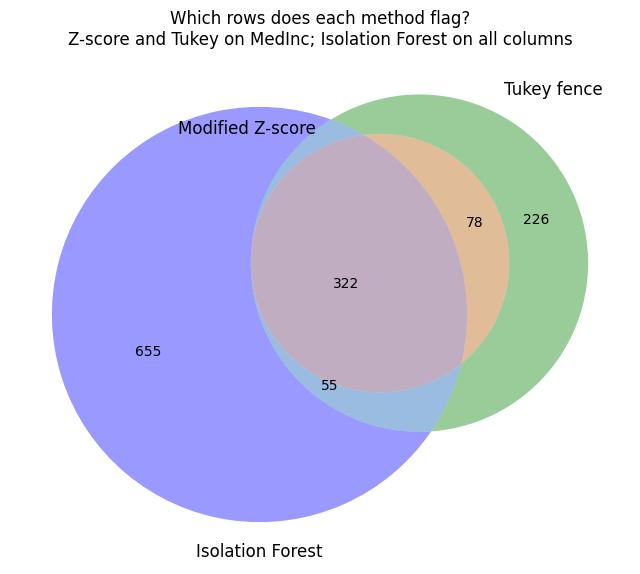

Total unique observations flagged: 1336
Flagged by >= 2 methods: 455 (34.1%)
Flagged by all 3: 322


In [19]:
# GUIDED — run as-is: draw the Venn diagram
from matplotlib_venn import venn3

fig, ax = plt.subplots(figsize=(8, 8))
venn3([set_z, set_t, set_i],
      set_labels=("Modified Z-score", "Tukey fence", "Isolation Forest"), ax=ax)
ax.set_title("Which rows does each method flag?\n"
             "Z-score and Tukey on MedInc; Isolation Forest on all columns")
plt.show()

any_flagged = set_z | set_t | set_i
at_least_two = z_and_t | z_and_i | t_and_i

print(f"Total unique observations flagged: {len(any_flagged)}")
print(f"Flagged by >= 2 methods: {len(at_least_two)} "
      f"({len(at_least_two) / len(any_flagged):.1%})")
print(f"Flagged by all 3: {len(all_three)}")

### Interpretation: Why Do Methods Disagree?

**Q1:** The Venn diagram likely shows limited overlap between Isolation Forest and the other two methods. Why? (Hint: think about what input each method receives.)

*Your answer here:*

Isolation Forest looks at all nine columns simultaneously and can flag a row for an unusual combination of features, while using a modified Z-score and Tukey only examine one column (MedInc) in isolation, so the three methods are detecting different kinds of anomalies.

**Q2:** Modified Z-score and Tukey are both analysizng a single variable and are robust, yet they flag different observations. Under what distribution shape would they agree most? Disagree most?

*Your answer here:*

Modified Z-score and Tukey would agree most on a symmetric, lightly-tailed distribution, like a normal distribution, and disagree most on a highly skewed one, like MedInc, since Tukey's quartile-based fences shift asymmetrically with skew while the median and MAD-based Z-score does not.

### Method Selection Memo (200 words)

You are a data scientist advising a policy team that uses California Housing data to allocate affordable-housing funding. They ask: "Which outlier detection method should we use to clean this data before modeling?"

Write a 200-word memo recommending a method (or combination). Address:
1. Which method and why
2. What you would lose by choosing a different method
3. Whether "outlier" always means "should be removed"

---

*Your memo here:*

**Memo: Outlier Detection Method for analyzing Affordable Housing Data**

For this task, I recommend using a Modified Z-score alongside Isolation Forest, rather than either alone. Modified Z-score should screen individual variables like median income, since it relies on the median and MAD rather than the mean and standard deviation. This recommendation would keeps it stable even when a handful of extreme values are present, which matters given how skewed housing and income data typically are. Tukey fences are a reasonable alternative, but their quartile fences shift more aggressively on skewed distributions, making them more sensitive to the specific shape of each variable than the team should have to account for. Isolation Forest should run alongside it to catch multivariate anomalies. Or in other words it would run alongside rows that look unremarkable on any single variable but represent an implausible combination. An example of this would be if low housing variables are paired with extremely high income.

Choosing only one method means losing visibility into whatever kind of anomaly that method isn't built to catch. For example an univariate methods alone misses multivariate irregularities, while Isolation Forest alone misses interpretable, variable specific flags.

Critically, "outlier" should not automatically mean "remove." Some flagged rows represent real, extreme communities the funding model needs to serve well, not data errors. So, removing them could systematically exclude the very areas most in need. Every flagged row deserves a documented, case by case decision before removal.



---
## AI-Assisted Expansion: Outlier Method Explorer

**AI policy: foundations first, expansion second.** You have fixed the pipeline, built `OutlierDetector` and compared the three methods by hand. From here on, AI may write code for you (the Co-Pilot Rule).

### Your Expansion Task
Build ONE interactive explorer, inside this notebook (ipywidgets + plotly), that lets the user:
1. Pick a California Housing column
2. Tune each method's parameter — modified Z-score `threshold`, Tukey `k`, Isolation Forest `contamination`
3. See how many observations each method flags and how many all three agree on
4. Click through the flagged rows to decide whether they are errors or real extremes

Import your `OutlierDetector`; do not rewrite it.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# AI EXPANSION — copy the prompt below into Claude, then paste
# its code at the bottom of this cell. Run it and check it.

# [Prep] Act as an expert Python data scientist specializing
# in robust statistics and anomaly detection.
#
# [Request] I just completed a diagnosis-first lab where I fixed
# three bugs in an outlier pipeline and built an OutlierDetector
# class with method in {'zscore', 'tukey', 'isolation_forest'},
# threshold, k, contamination, a fit_detect() method and a
# summary() method, then compared the three methods on
# California Housing. Build ONE interactive explorer in Colab:
#   1. a column dropdown over the housing DataFrame df
#   2. sliders for threshold (modified Z), k (Tukey) and
#      contamination (Isolation Forest)
#   3. counts flagged by each method and by all three
#   4. a table of the flagged rows for the selected method
#
# [Iterate] Use ipywidgets, plotly and pandas. Import
# OutlierDetector from outlier_detector and reuse df. No
# Streamlit and no new .py file.
#
# [Mechanism Check] Add inline comments explaining:
#   - why the modified Z-score uses the median and MAD with the
#     0.6745 constant
#   - why Tukey fences are asymmetric on skewed data
#   - why Isolation Forest can flag rows the univariate methods
#     never will
#
# [Evaluate] Explain whether "flagged" should ever mean
# "removed" for a policy team allocating housing funds.

# PASTE AI-GENERATED CODE BELOW:

In [20]:
# AI EXPANSION WRONG CODE

import ipywidgets as widgets
import plotly.graph_objects as go
import pandas as pd
from IPython.display import display
from outlier_detector import OutlierDetector

numeric_cols = df.columns

column_dropdown = widgets.Dropdown(options=list(numeric_cols), value="MedInc", description="Column:")
threshold_slider = widgets.FloatSlider(value=3.5, min=1.0, max=6.0, step=0.1, description="Z threshold:", style={"description_width": "initial"}, continuous_update=False)
k_slider = widgets.FloatSlider(value=1.5, min=0.5, max=3.0, step=0.1, description="Tukey k:", style={"description_width": "initial"}, continuous_update=False)
contamination_slider = widgets.FloatSlider(value=0.05, min=0.01, max=0.45, step=0.01, description="IF contamination:", style={"description_width": "initial"}, continuous_update=False)
counts_out = widgets.Output()
table_out = widgets.Output()

def update_explorer(change=None):
    col = column_dropdown.value
    series = df[col]

    # Modified Z-score uses the MEDIAN and MAD (median absolute deviation)
    # instead of mean/std because both the mean and standard deviation are
    # themselves pulled around by extreme values -- the exact thing being
    # detected. Median and MAD stay anchored near the bulk of the data
    # regardless of how extreme a handful of outliers are. The 0.6745
    # constant rescales the MAD so it is comparable to a standard
    # deviation under a normal distribution (MAD * 1.4826 ≈ std for
    # normal data; 0.6745 is the reciprocal-style scaling used in the
    # numerator so the resulting z-like score has roughly unit variance).
    det_z = OutlierDetector(method="zscore", threshold=threshold_slider.value)
    mask_z = det_z.fit_detect(series)

    # Tukey fences are built from Q1 and Q3, which are NOT symmetric
    # around the median on a skewed distribution. On right-skewed data
    # (like MedInc), Q3 sits much farther from the median than Q1 does,
    # so the upper fence (Q3 + k*IQR) extends much farther out than the
    # lower fence (Q1 - k*IQR) implies -- the fence asymmetry mirrors the
    # data's own asymmetry.
    det_t = OutlierDetector(method="tukey", k=k_slider.value)
    mask_t = det_t.fit_detect(series)

    # Isolation Forest sees ALL numeric columns at once, so it can flag a
    # row for an unusual COMBINATION of values even when every individual
    # column looks unremarkable on its own -- something a univariate
    # method (zscore or tukey) structurally cannot detect, since each of
    # those only ever looks at one column in isolation.
    det_i = OutlierDetector(method="isolation_forest", contamination=contamination_slider.value)
    mask_i = det_i.fit_detect(df[numeric_cols])

    all_three = mask_z & mask_t & mask_i

    with counts_out:
        counts_out.clear_output(wait=True)
        print(f"Modified Z-score flagged: {mask_z.sum()} ({mask_z.mean():.1%})")
        print(f"Tukey flagged:            {mask_t.sum()} ({mask_t.mean():.1%})")
        print(f"Isolation Forest flagged: {mask_i.sum()} ({mask_i.mean():.1%})")
        print(f"Flagged by all three:     {all_three.sum()}")

    with table_out:
        table_out.clear_output(wait=True)
        flagged_rows = df.loc[mask_z, [col]].sort_values(col, ascending=False)
        print(f"Rows flagged by Modified Z-score on '{col}' (showing up to 20):")
        display(flagged_rows.head(20))

for w in

SyntaxError: invalid syntax (3206483396.py, line 98)

In [22]:
### THE CORRRECTED AI CODE after explicitly stating the issues and what to fix
## It passed!!

import ipywidgets as widgets
import plotly.graph_objects as go
import pandas as pd
from IPython.display import display
from outlier_detector import OutlierDetector

numeric_cols = df.columns

column_dropdown = widgets.Dropdown(options=list(numeric_cols), value="MedInc", description="Column:")
threshold_slider = widgets.FloatSlider(value=3.5, min=1.0, max=6.0, step=0.1, description="Z threshold:", style={"description_width": "initial"}, continuous_update=False)
k_slider = widgets.FloatSlider(value=1.5, min=0.5, max=3.0, step=0.1, description="Tukey k:", style={"description_width": "initial"}, continuous_update=False)
contamination_slider = widgets.FloatSlider(value=0.05, min=0.01, max=0.45, step=0.01, description="IF contamination:", style={"description_width": "initial"}, continuous_update=False)
counts_out = widgets.Output()
table_out = widgets.Output()

def update_explorer(change=None):
    col = column_dropdown.value
    series = df[col]

    # Modified Z-score uses the MEDIAN and MAD (median absolute deviation)
    # instead of mean/std because both the mean and standard deviation are
    # themselves pulled around by extreme values -- the exact thing being
    # detected. Median and MAD stay anchored near the bulk of the data
    # regardless of how extreme a handful of outliers are. The 0.6745
    # constant rescales the MAD so the resulting score is comparable to a
    # standard z-score under a normal distribution.
    det_z = OutlierDetector(method="zscore", threshold=threshold_slider.value)
    mask_z = det_z.fit_detect(series)

    # Tukey fences are built from Q1 and Q3, which are NOT symmetric
    # around the median on a skewed distribution. On right-skewed data
    # (like MedInc), Q3 sits much farther from the median than Q1 does,
    # so the upper fence (Q3 + k*IQR) extends much farther out than the
    # lower fence implies -- the fence asymmetry mirrors the data's own
    # asymmetry.
    det_t = OutlierDetector(method="tukey", k=k_slider.value)
    mask_t = det_t.fit_detect(series)

    # Isolation Forest sees ALL numeric columns at once, so it can flag a
    # row for an unusual COMBINATION of values even when every individual
    # column looks unremarkable on its own -- something a univariate
    # method (zscore or tukey) structurally cannot detect, since each of
    # those only ever looks at one column in isolation.
    det_i = OutlierDetector(method="isolation_forest", contamination=contamination_slider.value)
    mask_i = det_i.fit_detect(df[numeric_cols])

    all_three = mask_z & mask_t & mask_i

    with counts_out:
        counts_out.clear_output(wait=True)
        print(f"Modified Z-score flagged: {mask_z.sum()} ({mask_z.mean():.1%})")
        print(f"Tukey flagged:            {mask_t.sum()} ({mask_t.mean():.1%})")
        print(f"Isolation Forest flagged: {mask_i.sum()} ({mask_i.mean():.1%})")
        print(f"Flagged by all three:     {all_three.sum()}")

    with table_out:
        table_out.clear_output(wait=True)
        flagged_rows = df.loc[mask_z, [col]].sort_values(col, ascending=False)
        print(f"Rows flagged by Modified Z-score on '{col}' (showing up to 20):")
        display(flagged_rows.head(20))

watched_widgets = [column_dropdown, threshold_slider, k_slider, contamination_slider]
for w in watched_widgets:
    w.observe(update_explorer, names="value")

ui = widgets.VBox([column_dropdown, threshold_slider, k_slider, contamination_slider, counts_out, table_out])
display(ui)
update_explorer()

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. The AI's for w in (column_dropdown, threshold_slider, k_slider, contamination_slider): line used a multiple item tuple that got cut off mid paste and raised a SyntaxError, so I had asked the code to rewrite it as a list built on its own line first.
2. At the default slider settings (threshold=3.5, k=1.5, contamination=0.05) on the MedInc column, the dashboard shows 400 Z-score flags and 681 Tukey flags, matching the values computed in Part 1's verification checkpoint.
3. I'd explicitly ask the AI to avoid tuples or multi-item literals inside for loop headers, since that formatting choice was the direct cause of the syntax error that needed to be fixed.

---
## Digital Portfolio: your README

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [ ]:
# README prompt — documentation only, no code

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed three bugs in an outlier-detection pipeline
# * Used an OutlierDetector class (modified Z-score, Tukey fences,
#   Isolation Forest) that checks its settings and reports a summary
# * Modified Z-score on MedInc flagged [YOUR VALUE], Tukey on MedInc
#   [YOUR VALUE], Isolation Forest on all 9 columns [YOUR VALUE];
#   all three agreed on [YOUR VALUE]
# * Wrote a method-selection memo recommending [YOUR VALUE]
# * Built an interactive outlier method explorer
#
# **Please write a README.md entry including:**
# 1. Project Title: Outlier Detection on California Housing
# 2. Objective: one sentence
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Write it plainly, in the first person. No words like 'robust',
# 'comprehensive' or 'leverage'. Use only the numbers I gave you."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab04-outlier-pipeline`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab04-outlier-pipeline`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab04-outlier-pipeline`, branch `main`,
   commit message `Lab 04 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `outlier_detector.py` is **not** pushed by step 2 — that step sends the notebook only,
   and the file lives in Colab's temporary storage, which is wiped when the
   session ends. Download it first: in the Colab **Files** panel (folder icon,
   left), right-click `outlier_detector.py` → **Download**. Then on the repo page use
   **Add file → Upload files**, drag it in, and **Commit changes**. It is part
   of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**End of Lab 4.** You fixed three bugs in an outlier pipeline, ran the same
three methods through one class, and saw that they flag different rows. Which
rows count as outliers is a choice you make and defend, not something the data
decides for you.